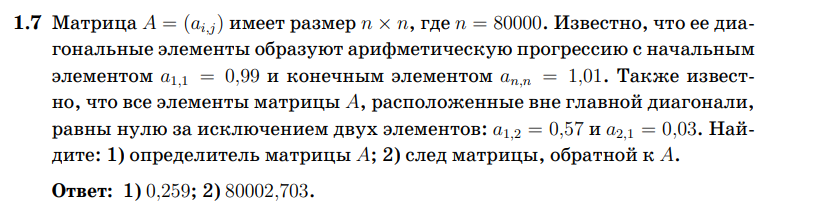

# Решение задачи о матрице специального вида


---

## Основные определения

### Блочно-диагональная матрица

**Блочно-диагональная матрица** — это квадратная матрица, имеющая блочную структуру, где все блоки вне главной диагонали являются нулевыми матрицами.

$$A = \begin{pmatrix}
A_1 & 0 & \cdots & 0 \\
0 & A_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & A_k
\end{pmatrix}$$

где:
- $A_1, A_2, \ldots, A_k$ — квадратные матрицы (блоки) на главной диагонали
- Все остальные блоки — нулевые матрицы соответствующих размеров

**Ключевое свойство**: Определитель блочно-диагональной матрицы равен произведению определителей её диагональных блоков:

$$\det(A) = \det(A_1) \cdot \det(A_2) \cdot \ldots \cdot \det(A_k)$$

### След матрицы

**След матрицы** (обозначается $\text{tr}(A)$ или $\text{Sp}(A)$) — сумма диагональных элементов квадратной матрицы $A = (a_{ij})$ размера $n \times n$:

$$\text{tr}(A) = \sum_{i=1}^{n} a_{ii} = a_{11} + a_{22} + \ldots + a_{nn}$$

**Основные свойства следа**:
1. Линейность: $\text{tr}(A + B) = \text{tr}(A) + \text{tr}(B)$
2. Инвариантность относительно циклической перестановки: $\text{tr}(AB) = \text{tr}(BA)$
3. След обратной матрицы: $\text{tr}(A^{-1}) = \sum_{i=1}^{n} \frac{1}{\lambda_i}$, где $\lambda_i$ — собственные значения матрицы $A$

---

## Необходимые теоремы и формулы

### 1. Определитель матрицы 2×2

Для матрицы $B = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$:

$$\det(B) = ad - bc$$

### 2. Обратная матрица 2×2

$$B^{-1} = \frac{1}{\det(B)} \begin{pmatrix} d & -b \\ -c & a \end{pmatrix}$$

### 3. След обратной матрицы 2×2

$$\text{tr}(B^{-1}) = \frac{a + d}{\det(B)}$$

### 4. Арифметическая прогрессия

$n$-й член арифметической прогрессии:

$$a_n = a_1 + (n-1)d$$

Разность прогрессии:

$$d = \frac{a_n - a_1}{n-1}$$

### 5. Определитель диагональной матрицы

Для диагональной матрицы $D = \text{diag}(d_1, d_2, \ldots, d_m)$:

$$\det(D) = \prod_{i=1}^{m} d_i$$

### 6. След обратной диагональной матрицы

Для диагональной матрицы $D = \text{diag}(d_1, d_2, \ldots, d_m)$:

$$\text{tr}(D^{-1}) = \sum_{i=1}^{m} \frac{1}{d_i}$$

### 7. Логарифмирование произведения

Для избежания переполнения при вычислении произведения большого числа элементов:

$$\ln\left(\prod_{i=1}^{n} a_i\right) = \sum_{i=1}^{n} \ln(a_i)$$

$$\prod_{i=1}^{n} a_i = \exp\left(\sum_{i=1}^{n} \ln(a_i)\right)$$

---

## Алгоритм решения

### Шаг 1: Анализ структуры матрицы

Дана матрица $A$ размера $n \times n$, где $n = 80000$:

- Диагональные элементы: $a_{ii}$ образуют арифметическую прогрессию
  - $a_{11} = 0.99$
  - $a_{nn} = 1.01$

- Внедиагональные элементы: все равны 0, кроме:
  - $a_{12} = 0.57$
  - $a_{21} = 0.03$

Структура матрицы:

$$A = \begin{pmatrix}
0.99 & 0.57 & 0 & 0 & \cdots & 0 \\
0.03 & a_{22} & 0 & 0 & \cdots & 0 \\
0 & 0 & a_{33} & 0 & \cdots & 0 \\
0 & 0 & 0 & a_{44} & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & 0 & \cdots & a_{nn}
\end{pmatrix}$$

Это **блочно-диагональная матрица** вида:

$$A = \begin{pmatrix} B & 0 \\ 0 & D \end{pmatrix}$$

где:
- $B = \begin{pmatrix} 0.99 & 0.57 \\ 0.03 & a_{22} \end{pmatrix}$ — блок $2 \times 2$
- $D = \text{diag}(a_{33}, a_{44}, \ldots, a_{nn})$ — диагональная матрица размера $(n-2) \times (n-2)$

### Шаг 2: Вычисление параметров арифметической прогрессии

**Разность прогрессии**:

$$d = \frac{a_{nn} - a_{11}}{n - 1} = \frac{1.01 - 0.99}{80000 - 1} = \frac{0.02}{79999}$$

**Общая формула** для диагональных элементов:

$$a_{ii} = a_{11} + (i-1) \cdot d = 0.99 + (i-1) \cdot \frac{0.02}{79999}$$

**Второй диагональный элемент**:

$$a_{22} = 0.99 + 1 \cdot \frac{0.02}{79999} \approx 0.990000250$$

### Шаг 3: Вычисление определителя матрицы $A$

Используем свойство блочно-диагональной матрицы:

$$\det(A) = \det(B) \cdot \det(D)$$

#### 3.1. Определитель блока $B$:

$$\det(B) = 0.99 \cdot a_{22} - 0.57 \cdot 0.03 = 0.99 \cdot a_{22} - 0.0171$$

#### 3.2. Определитель матрицы $D$:

$$\det(D) = \prod_{i=3}^{n} a_{ii} = \prod_{i=3}^{80000} \left(0.99 + (i-1) \cdot \frac{0.02}{79999}\right)$$

Для вычисления используем логарифмы (избегаем переполнения):

$$\ln(\det(D)) = \sum_{i=3}^{n} \ln(a_{ii})$$

$$\det(D) = \exp\left(\sum_{i=3}^{n} \ln(a_{ii})\right)$$

#### 3.3. Итоговый определитель:

$$\det(A) = \det(B) \cdot \det(D)$$

### Шаг 4: Вычисление следа обратной матрицы $A^{-1}$

Обратная матрица сохраняет блочно-диагональную структуру:

$$A^{-1} = \begin{pmatrix} B^{-1} & 0 \\ 0 & D^{-1} \end{pmatrix}$$

След обратной матрицы:

$$\text{tr}(A^{-1}) = \text{tr}(B^{-1}) + \text{tr}(D^{-1})$$

#### 4.1. След обратной матрицы $B^{-1}$:

$$\text{tr}(B^{-1}) = \frac{0.99 + a_{22}}{\det(B)}$$

#### 4.2. След обратной матрицы $D^{-1}$:

$$\text{tr}(D^{-1}) = \sum_{i=3}^{n} \frac{1}{a_{ii}} = \sum_{i=3}^{80000} \frac{1}{0.99 + (i-1) \cdot \frac{0.02}{79999}}$$

#### 4.3. Итоговый след:

$$\text{tr}(A^{-1}) = \frac{0.99 + a_{22}}{\det(B)} + \sum_{i=3}^{80000} \frac{1}{a_{ii}}$$


In [2]:
import numpy as np
import math

# Параметры задачи
n = 80000
a1 = 0.99
an = 1.01

# Разность арифметической прогрессии
d = (an - a1) / (n - 1)

# Второй диагональный элемент
a22 = a1 + d

# Определитель блока 2x2: det(B) = a11*a22 - a12*a21
det_B = a1 * a22 - 0.57 * 0.03

# Определитель диагональной матрицы D через логарифмы (избегаем переполнения)
log_det_D = sum(math.log(a1 + i * d) for i in range(2, n))
det_D = math.exp(log_det_D)

# Итоговый определитель матрицы A
det_A = det_B * det_D

# След обратной матрицы B: tr(B^-1) = (a11 + a22) / det(B)
tr_B_inv = (a1 + a22) / det_B

# След обратной матрицы D: сумма обратных диагональных элементов
tr_D_inv = sum(1.0 / (a1 + i * d) for i in range(2, n))

# Итоговый след обратной матрицы A
tr_A_inv = tr_B_inv + tr_D_inv

# Вывод результатов
print(f"1) det(A) = {det_A:.3f}")
print(f"2) tr(A^-1) = {tr_A_inv:.3f}")

1) det(A) = 0.259
2) tr(A^-1) = 80002.703
